### K-Means Clustering

- find clusters /groups within the dataset based on the income and spwnding Scorem

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### LOad the Data

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### EDA 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### data prepration

In [7]:
# Since the clusters based on the annual income and spending score
# so drop ather columns
df.drop(['CustomerID','Age','Gender'],axis=1,inplace=True)

In [8]:
#rename the annual income 
df.rename({"Annual Income (k$)":"income","Spending Score (1-100)":"spending_score"},inplace=True,axis=1)

In [9]:
df

,income,spending_score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Data Visualization

Text(0, 0.5, 'Spending Score')

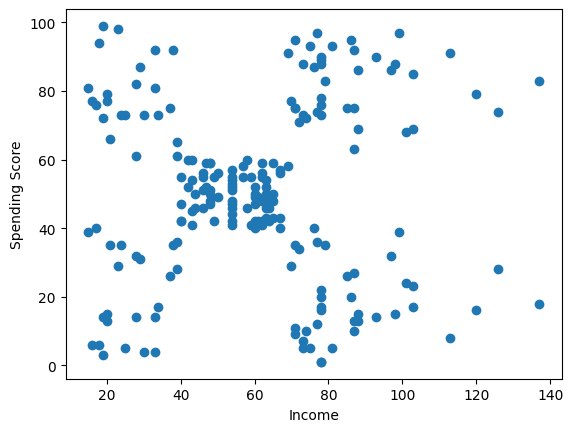

In [10]:
plt.scatter(df['income'],df['spending_score'])
plt.xlabel("Income")
plt.ylabel("Spending Score")

### Create the Clusters Using the Kmeans

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5)
kmeans.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)",

### Get the clusters positions 

In [12]:
kmeans.labels_

array([2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [13]:
# C entroids Values
kmeans.cluster_centers_

array([[ 48.26      ,  56.48      ],
       [ 86.53846154,  82.12820513],
       [ 26.30434783,  20.91304348],
       [109.7       ,  22.        ],
       [ 78.89285714,  17.42857143]])

### Cluster Visualiztion

<Axes: xlabel='income', ylabel='spending_score'>

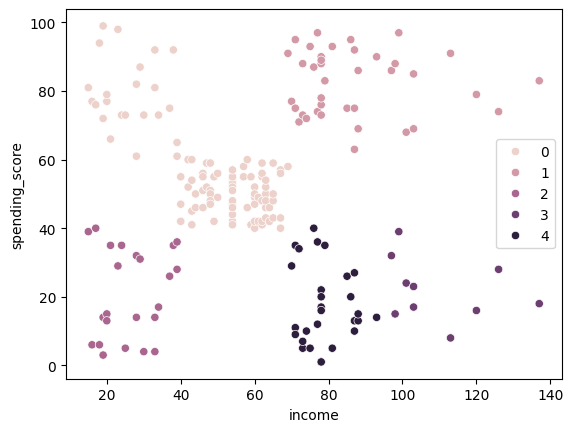

In [14]:
sns.scatterplot(df,x='income',y='spending_score',hue=kmeans.labels_)

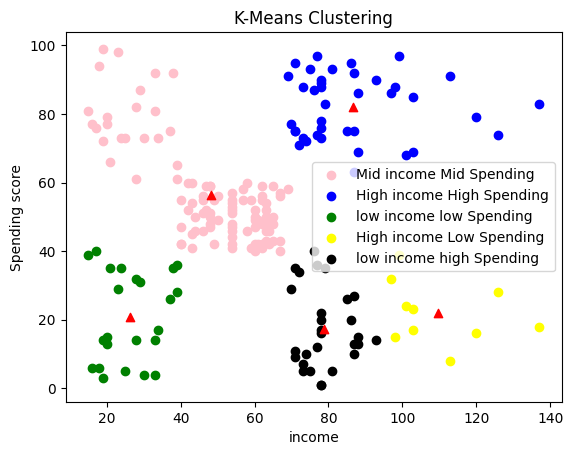

In [15]:
plt.scatter(df['income'][kmeans.labels_==0],df['spending_score'][kmeans.labels_==0],color='pink',label='Mid income Mid Spending')
plt.scatter(df['income'][kmeans.labels_==1],df['spending_score'][kmeans.labels_==1],color='blue',label='High income High Spending')
plt.scatter(df['income'][kmeans.labels_==2],df['spending_score'][kmeans.labels_==2],color='green',label='low income low Spending')
plt.scatter(df['income'][kmeans.labels_==3],df['spending_score'][kmeans.labels_==3],color='yellow',label='High income Low Spending')
plt.scatter(df['income'][kmeans.labels_==4],df['spending_score'][kmeans.labels_==4],color='black',label='low income high Spending')
plt.xlabel('income')
plt.ylabel('Spending score')
plt.title('K-Means Clustering')
plt.legend()

## Add centroids
plt.scatter(kmeans.cluster_centers_[0][0],kmeans.cluster_centers_[0][1],color='red',marker='^')
plt.scatter(kmeans.cluster_centers_[1][0],kmeans.cluster_centers_[1][1],color='red',marker='^')
plt.scatter(kmeans.cluster_centers_[2][0],kmeans.cluster_centers_[2][1],color='red',marker='^')
plt.scatter(kmeans.cluster_centers_[3][0],kmeans.cluster_centers_[3][1],color='red',marker='^')
plt.scatter(kmeans.cluster_centers_[4][0],kmeans.cluster_centers_[4][1],color='red',marker='^')

### Convert the unlabelled to labelled data

In [16]:
df['Segment'] = kmeans.labels_

In [17]:
df.head()

,income,spending_score,Segment
0,15,39,2
1,15,81,0
2,16,6,2
3,16,77,0
4,17,40,2


In [18]:
df.corr()

,income,spending_score,Segment
income,1.000000,0.009903,0.394548
spending_score,0.009903,1.000000,-0.625088
Segment,0.394548,-0.625088,1.000000


In [19]:
# Split the data
x=df.drop('Segment',axis=1)
y = df['Segment']

In [20]:
#Split the Dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(max_iter=1000)
model.fit(x_train,y_train)

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifie

,"max_iter max_iter: int, default=100Maximum number of iterations of the optimization algorithm.",1000
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'warn'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'lib

In [22]:
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         5
           3       1.00      0.50      0.67         2
           4       0.93      1.00      0.96        13

    accuracy                           0.98        60
   macro avg       0.99      0.90      0.93        60
weighted avg       0.98      0.98      0.98        60



### Evalution of clusters

In [23]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df,kmeans.labels_)
score

0.46543778237275896

In [24]:
kmeans6 = KMeans(n_clusters=6)
kmeans6.fit(df)
score2 = silhouette_score(df,kmeans6.labels_)
score2

0.5401169738188064

In [25]:
kmeans4 = KMeans(n_clusters=4)
kmeans4.fit(df)
score3 = silhouette_score(df,kmeans4.labels_)
score3

0.49443738272215254